In [1]:
library(Seurat)
library(ggplot2)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode



In [2]:
 # Object path
object_path <- "./matrix/"
output_path <- "./result_LSA/"

In [3]:
scRNA_2018_Lake <- readRDS(paste0(object_path,"scRNA_2018_Lake.Rds"))
scRNA_2019_Jakel <- readRDS(paste0(object_path,"scRNA_2019_Jakel.Rds"))
scRNA_2021_Absinta <- readRDS(paste0(object_path,"scRNA_2021_Absinta.Rds"))
scRNA_2022_RRSPMS <- readRDS(paste0(object_path,"scRNA_2022_RRSPMS.Rds"))
scRNA_2019_Schirmer <- readRDS(paste0(object_path,"scRNA_2019_Schirmer.Rds"))

In [4]:
scRNA_2018_Lake$orig.ident = "2018_Lake"
scRNA_2019_Schirmer$orig.ident = "2019_Multi"
scRNA_2019_Jakel$orig.ident = "2019_AltOligHtg"
scRNA_2021_Absinta$orig.ident = "2021_LymMicAst"
scRNA_2022_RRSPMS$orig.ident = "2022_RRSPMS"

In [5]:
scRNA_2018_Lake$source.article = "Lake et al. 2018"
scRNA_2019_Schirmer$source.article = "Schirmer et al. 2019"
scRNA_2019_Jakel$source.article = "Jakel et al. 2019"
scRNA_2021_Absinta$source.article = "Absinta et al. 2021"
scRNA_2022_RRSPMS$source.article = "Kihara et al. 2022"

# I.data preprocess

In [6]:
scRNA.merged_datas5 <- merge(
    x = scRNA_2018_Lake, 
    y = c(scRNA_2019_Jakel,
          scRNA_2021_Absinta,
          scRNA_2022_RRSPMS,
          scRNA_2019_Schirmer))

In [7]:
scRNA.merged_datas5

An object of class Seurat 
43302 features across 166533 samples within 1 assay 
Active assay: RNA (43302 features, 0 variable features)
 2 layers present: counts, data

In [8]:
scRNA.merged_datas5[["percent.mt"]] <- PercentageFeatureSet(scRNA.merged_datas5, 
                                                            pattern = "^MT-")
scRNA.merged_datas5 <- subset(scRNA.merged_datas5, 
                              subset = nFeature_RNA > 200 & 
                              nFeature_RNA < 6000 & percent.mt < 5)

In [9]:
scRNA.list <- SplitObject(scRNA.merged_datas5, split.by = "orig.ident")

In [10]:
scRNA.list <- lapply(X = scRNA.list, FUN = function(x) {
    x <- NormalizeData(x, normalization.method = "LogNormalize", scale.factor = 10000)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 2000)
})

# II. Data Integration

In [11]:
features <- SelectIntegrationFeatures(object.list = scRNA.list)

In [12]:
scRNA.list.anchors <- FindIntegrationAnchors(
    object.list = scRNA.list, 
    anchor.features = features)

Scaling features for provided objects

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 14205 anchors

Filtering anchors

	Retained 4332 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 26512 anchors

Filtering anchors

	Retained 1575 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 33347 anchors

Filtering anchors

	Retained 3867 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 19029 anchors

Filtering anchors

	Retained 3418 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 28963 anchors

Filtering anchors

	Retained 5664 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 73658 anchors

Filtering anchors

	Retained 17141 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 26593 anchors

Filtering anchors

	Retained

In [13]:
scRNA.combined_datas5 <- IntegrateData(anchorset = scRNA.list.anchors)

Merging dataset 2 into 5

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 4 into 3

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 1 into 5 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Merging dataset 5 2 1 into 3 4

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



# III. Dimensional reduction

In [14]:
scRNA.combined_datas5 <- ScaleData(scRNA.combined_datas5)
scRNA.combined_datas5 <- RunPCA(
    scRNA.combined_datas5,
    features = VariableFeatures(scRNA.combined_datas5),
    npcs = 30)
scRNA.combined_datas5 <- RunUMAP(scRNA.combined_datas5, 
                                 reduction = "pca", dims = 1:30)
scRNA.combined_datas5 <- RunTSNE(scRNA.combined_datas5, 
                                 reduction = "pca", dims = 1:30)

Centering and scaling data matrix

PC_ 1 
Positive:  ST18, PLP1, TMEM144, MBP, MOBP, TF, UGT8, CERCAM, SLCO1A2, BCAS1 
	   CNP, SPOCK3, CRYAB, NEAT1, SPP1, MAL, LINC01608, HHIP, ERMN, HSPA1A 
	   SCD, CNDP1, PALM2, TLE4, CARNS1, OPALIN, FTL, HSPA1B, LINC01470, B2M 
Negative:  FAM155A, CSMD1, STXBP5L, FGF14, DLGAP1, NRG3, AGBL4, CCSER1, KCNQ5, DLGAP2 
	   NRXN1, PLCB1, OPCML, TENM2, SNTG1, RALYL, CACNA2D3, FRMPD4, ATRNL1, RIMS2 
	   LRRTM4, MYT1L, FGF12, CNTNAP5, SYT1, LRFN5, RBFOX1, MTUS2, GRM5, RGS7 
PC_ 2 
Positive:  SPOCK3, NRXN3, ST18, MBP, MOBP, PLP1, PDE1A, TMEM144, GRIA4, RYR2 
	   TF, UGT8, BCAS1, CALN1, NECAB1, HS3ST5, IQCJ-SCHIP1, SLCO1A2, CNTNAP2, CERCAM 
	   CDH8, KCNIP4, NEGR1, CNP, ROBO1, CDH12, PALM2, RBFOX1, LINC01608, DGKI 
Negative:  GLIS3, LRMDA, MAML2, PITPNC1, RFX4, NHSL1, PARD3, LINC01088, AC073941.1, SLC14A1 
	   WDR49, CD44, MARCH3, NPL, BMPR1B, TPD52L1, ST6GAL1, EFEMP1, FAM189A2, ZFP36L1 
	   ADGRV1, LMNTD1, ABR, SLC1A3, AKAP13, UTRN, SERPINI2, STON2, BNC2, PRK

In [15]:
scRNA.combined_datas5 <- FindNeighbors(scRNA.combined_datas5, 
                                       reduction = "pca", dims = 1:30)
scRNA.combined_datas5 <- FindClusters(scRNA.combined_datas5, resolution = 0.5)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 160547
Number of edges: 6617773

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9235
Number of communities: 33
Elapsed time: 120 seconds


6 singletons identified. 27 final clusters.



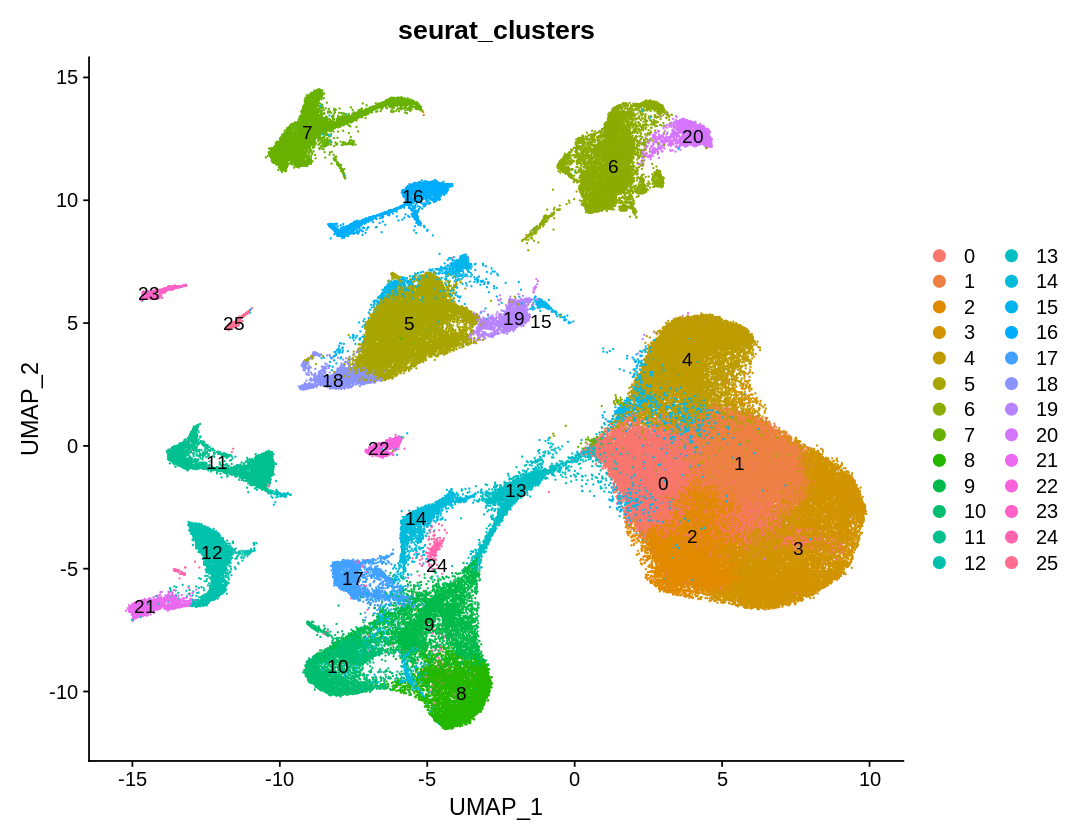

In [16]:
options(repr.plot.width = 9, repr.plot.height = 7)
DimPlot(scRNA.combined_datas5, reduction = "umap", 
        group.by = "seurat_clusters", 
        label = TRUE, raster=FALSE)

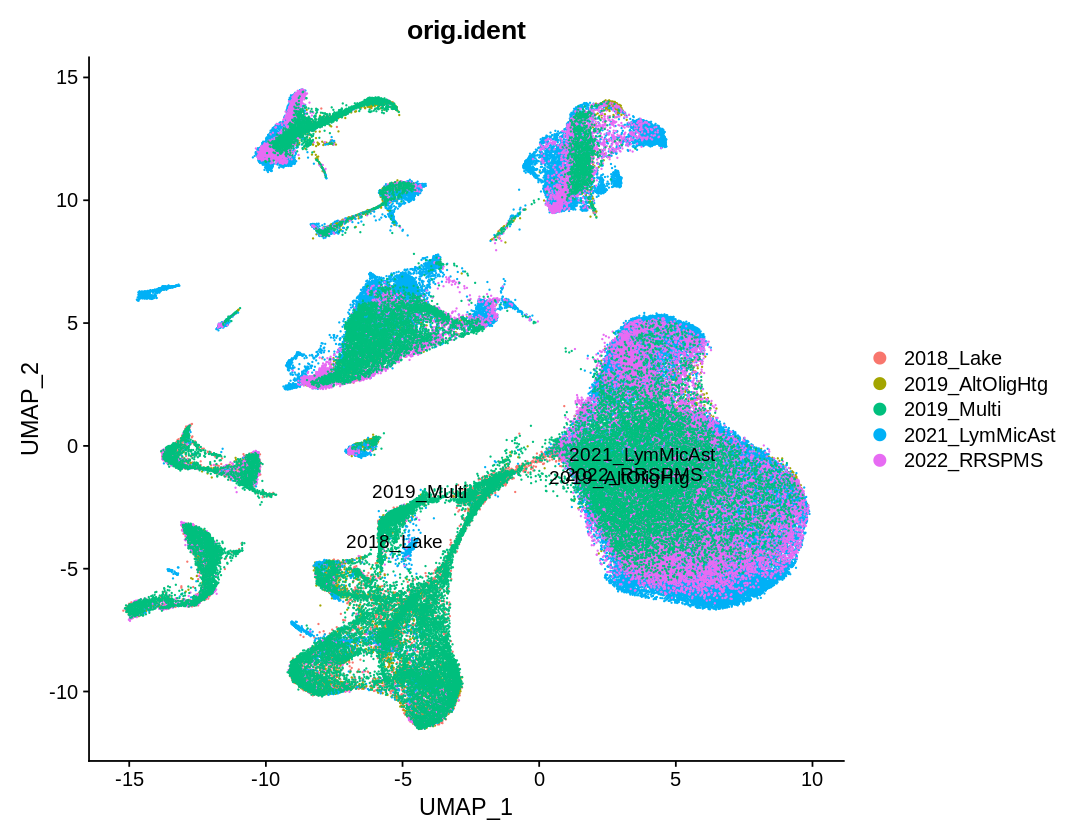

In [18]:
DimPlot(scRNA.combined_datas5, reduction = "umap", 
        group.by = "orig.ident", 
        label = TRUE, raster=FALSE)

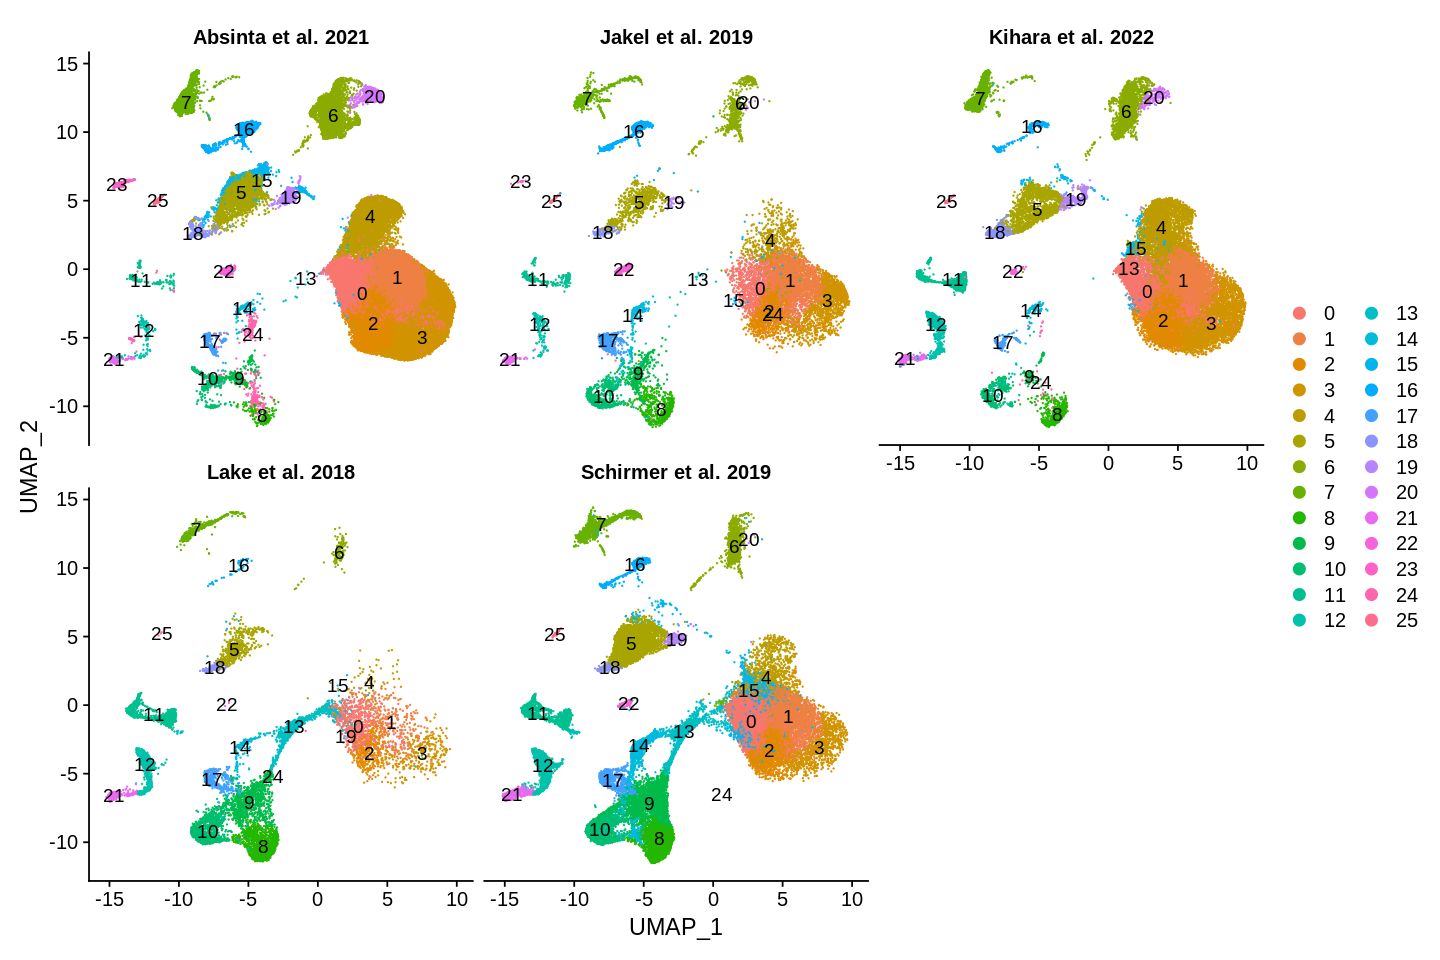

In [19]:
options(repr.plot.width = 12, repr.plot.height = 8)
DimPlot(scRNA.combined_datas5, reduction = "umap", 
        split.by = "source.article", ncol = 3,
        label = TRUE, raster = FALSE)

In [20]:
saveRDS(scRNA.combined_datas5, 
        paste0(output_path,"scRNA.combined_datas5.Rds"))

# IV. Cell type identify

In [21]:
DefaultAssay(scRNA.combined_datas5) <- "RNA"

### Oligodendrocytes

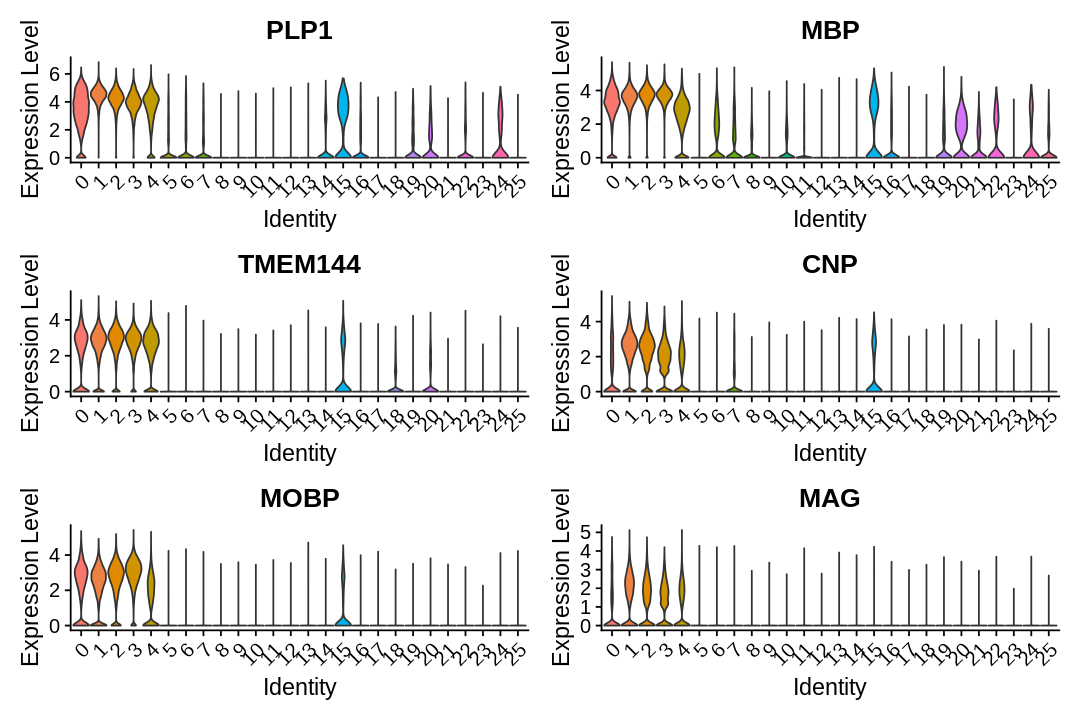

In [22]:
options(repr.plot.width = 9, repr.plot.height = 6)
oligodendrocyte_genes <- c("PLP1","MBP","TMEM144","CNP","MOBP","MAG")
VlnPlot(scRNA.combined_datas5, features = oligodendrocyte_genes, 
        pt.size=0, ncol=2, raster=FALSE)

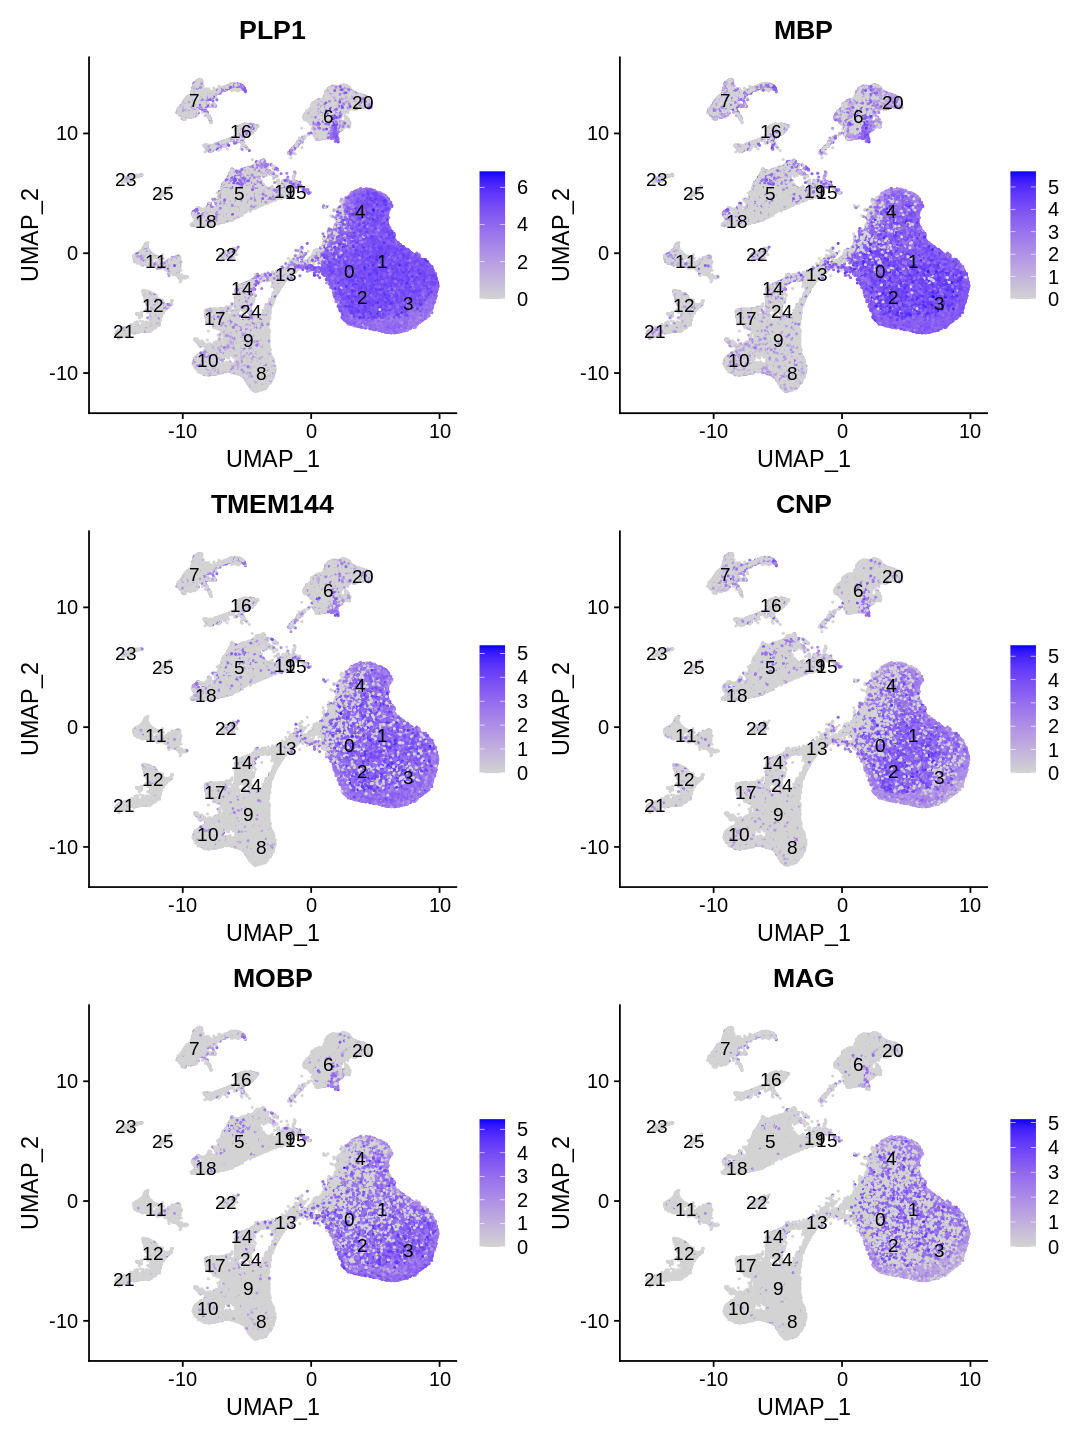

In [23]:
options(repr.plot.width = 9, repr.plot.height = 12)
FeaturePlot(scRNA.combined_datas5, features = oligodendrocyte_genes, 
            reduction = "umap", pt.size = 0.2, label=T, ncol=2, raster=FALSE)

### OPCs

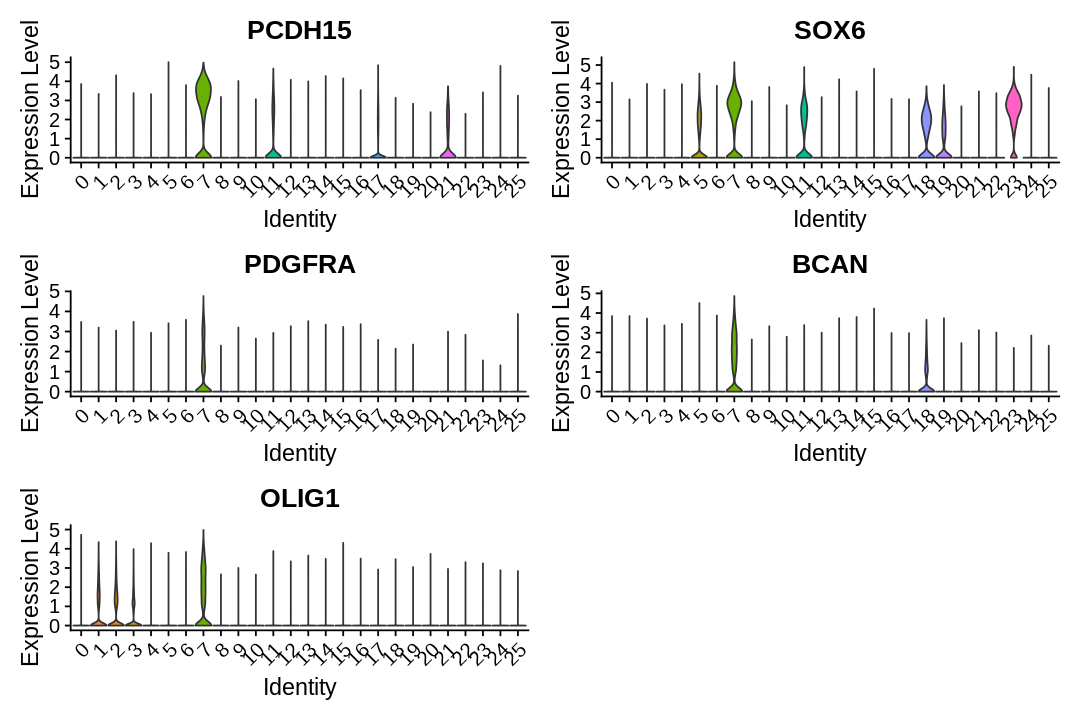

In [24]:
options(repr.plot.width = 9, repr.plot.height = 6)
OPC_genes <- c("PCDH15", "SOX6", "PDGFRA", "BCAN", "OLIG1")
VlnPlot(scRNA.combined_datas5, 
        features = OPC_genes, 
        pt.size=0, ncol=2, raster=FALSE)

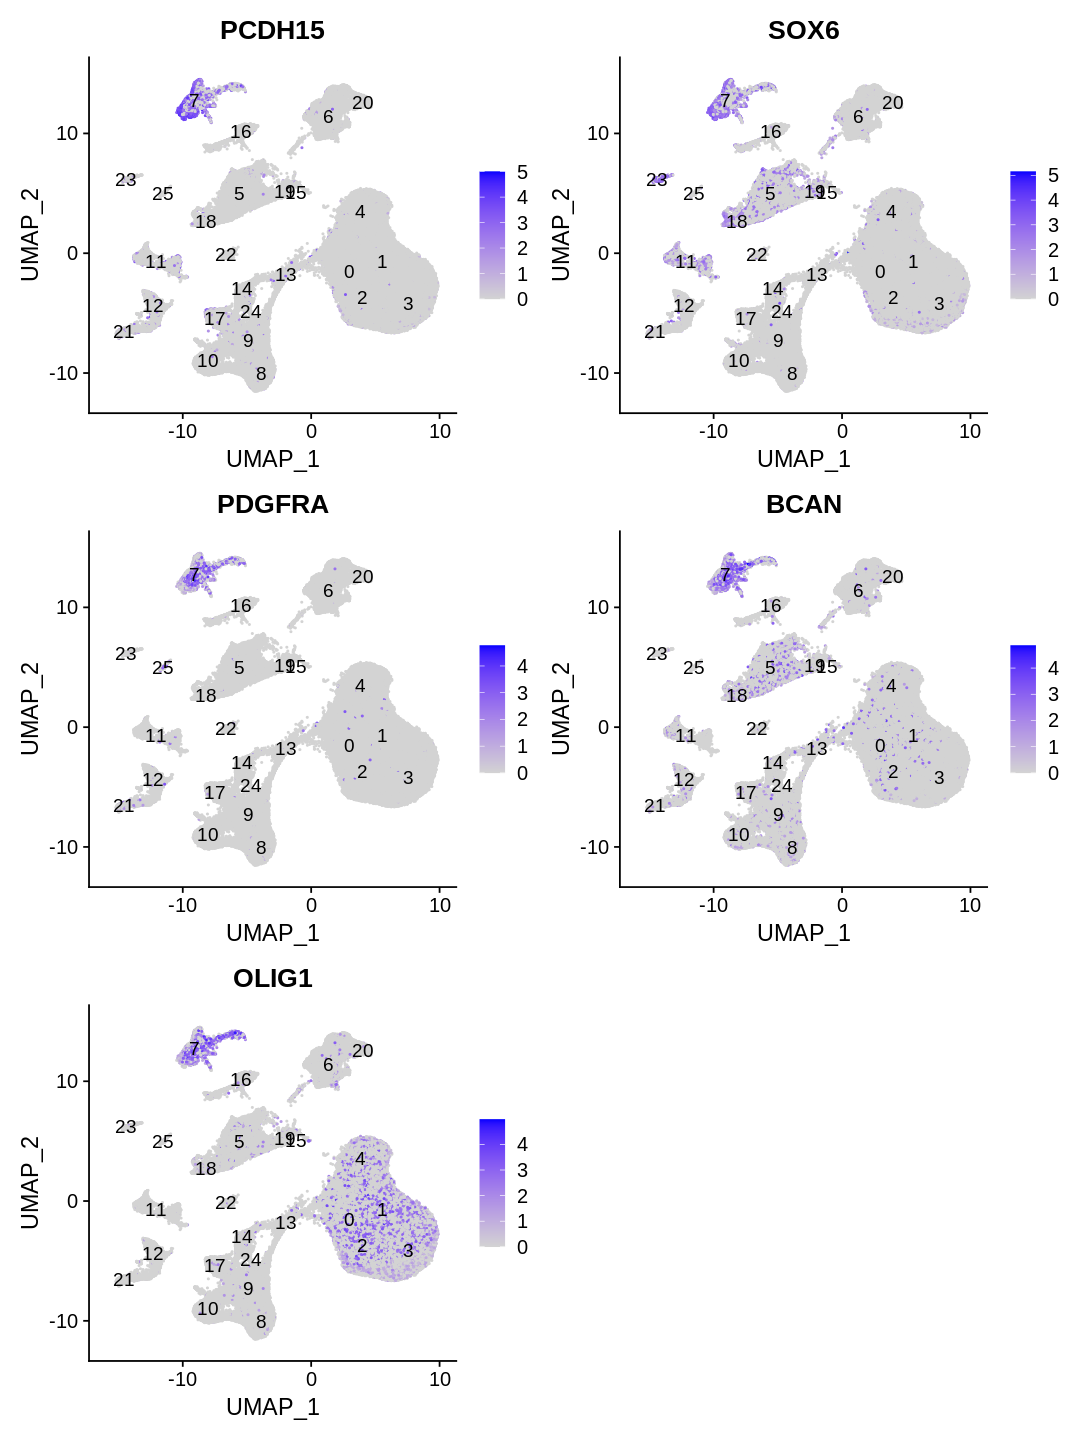

In [25]:
options(repr.plot.width = 9, repr.plot.height = 12)
FeaturePlot(scRNA.combined_datas5, features = OPC_genes, 
            reduction = "umap", pt.size = 0.2, 
            label=T, ncol=2, raster=FALSE)

### Neurons

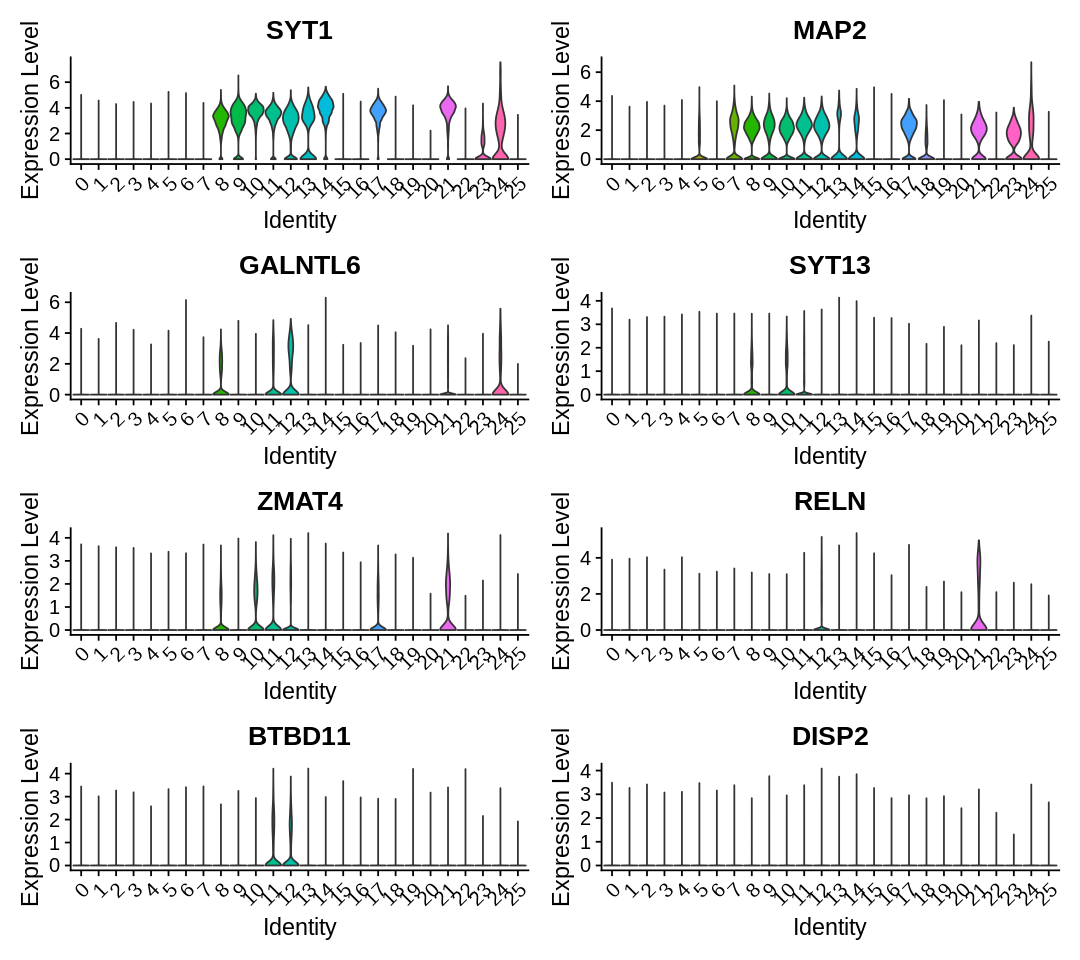

In [26]:
options(repr.plot.width = 9, repr.plot.height = 8)
neurons_genes <- c("SYT1", "MAP2", "GALNTL6", "SYT13", "ZMAT4", "RELN", 
                   "BTBD11", "DISP2")
VlnPlot(scRNA.combined_datas5, 
        features = neurons_genes, 
        pt.size=0, ncol=2, raster=FALSE)

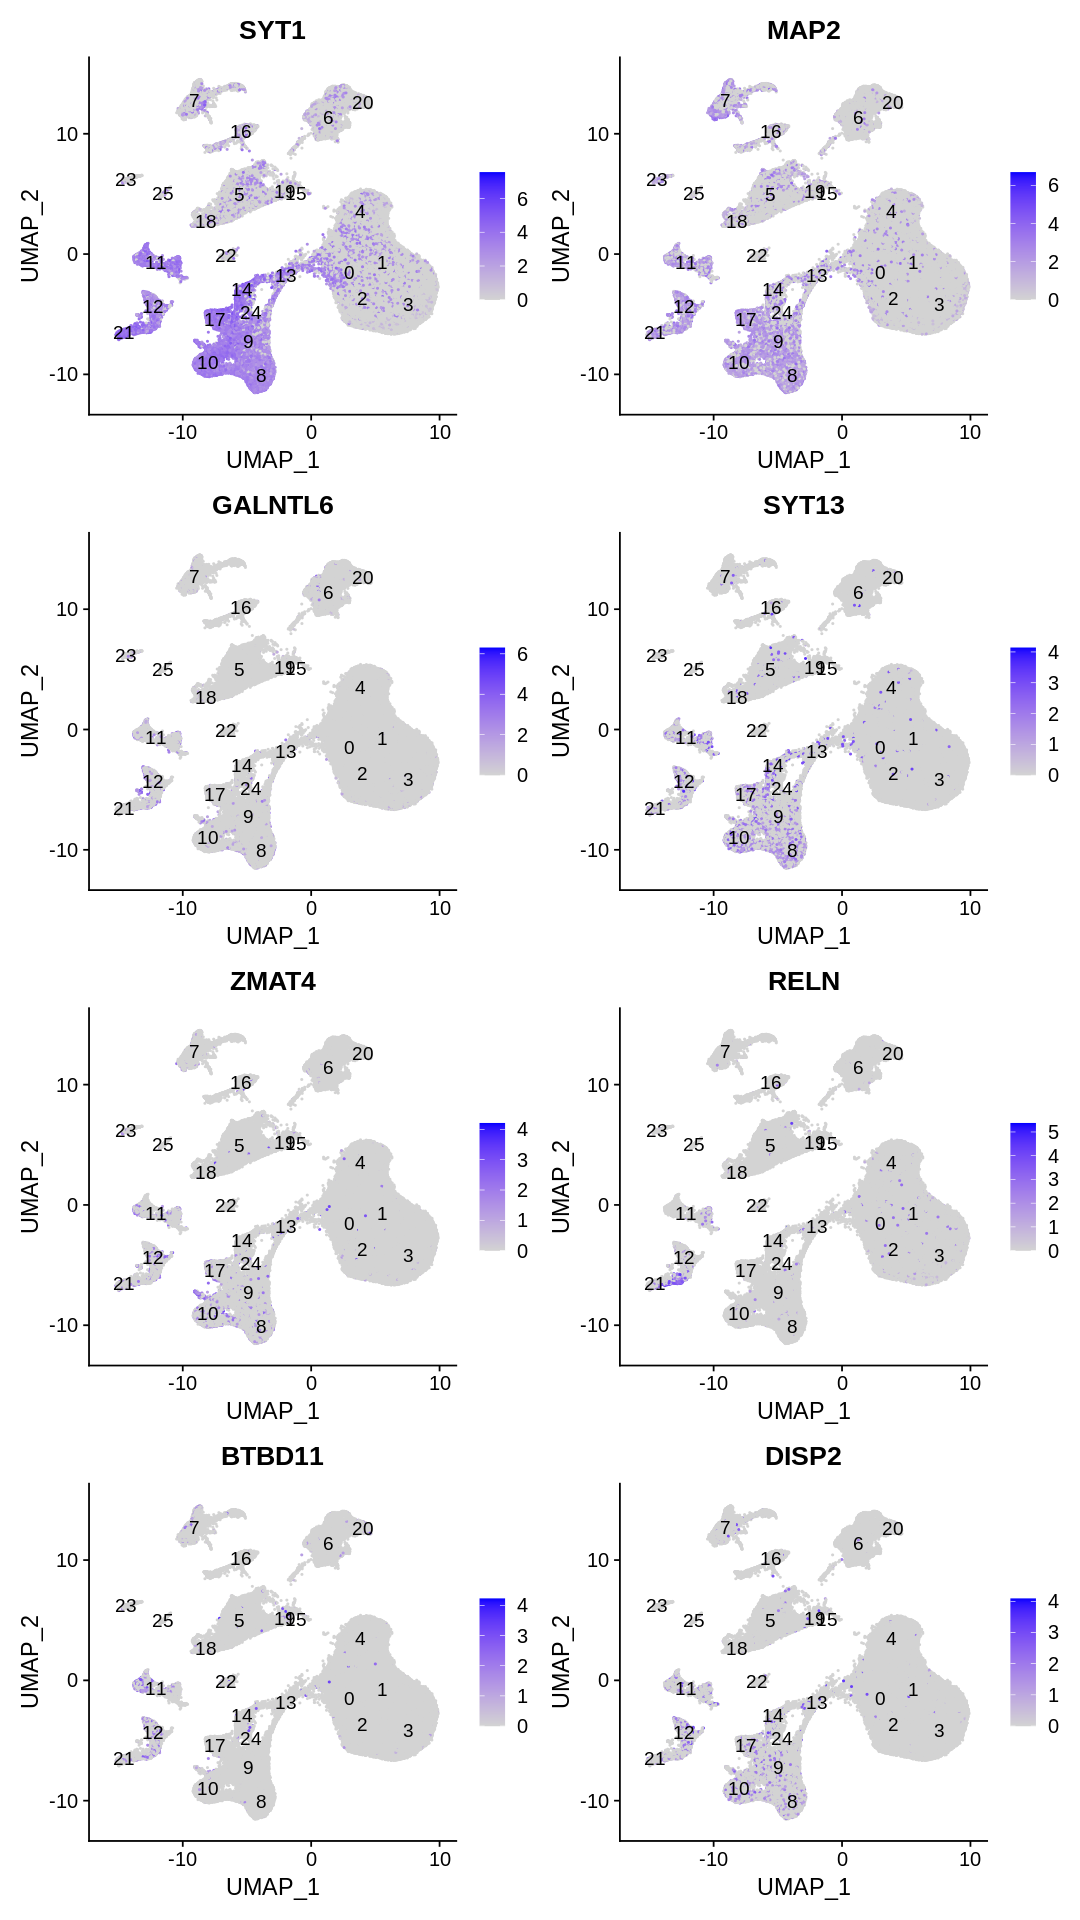

In [27]:
options(repr.plot.width = 9, repr.plot.height = 16)
FeaturePlot(scRNA.combined_datas5, features = neurons_genes, 
            reduction = "umap", pt.size = 0.2, 
            label=T, ncol=2, raster=FALSE)

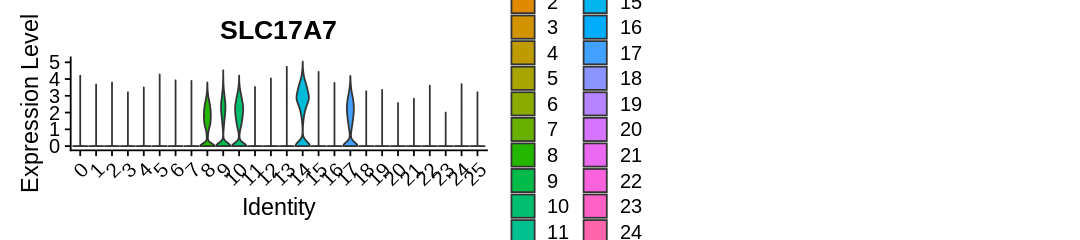

In [28]:
options(repr.plot.width = 9, repr.plot.height = 2)
exN_genes <- c("SLC17A7")
VlnPlot(scRNA.combined_datas5, 
        features = exN_genes, 
        pt.size=0, ncol = 2, raster = FALSE)

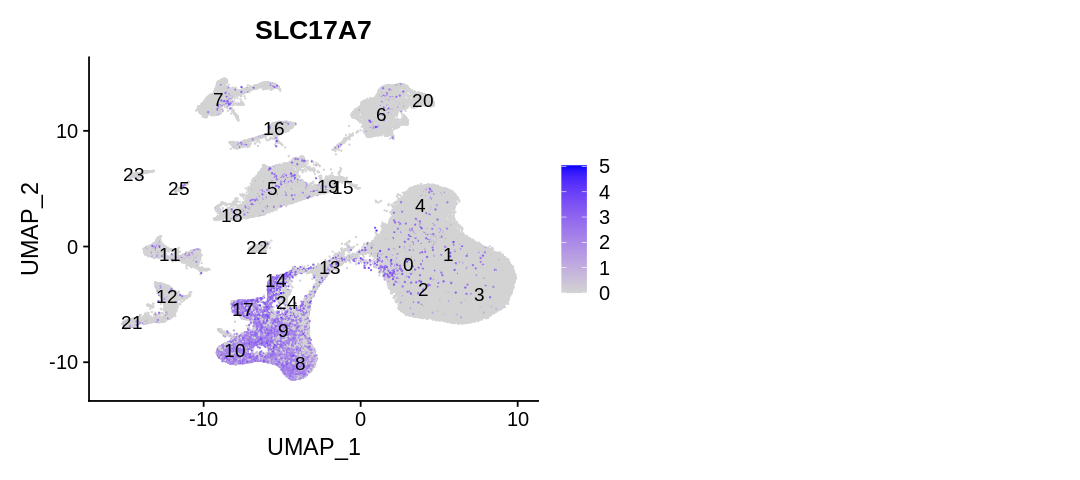

In [29]:
options(repr.plot.width = 9, repr.plot.height = 4)
FeaturePlot(scRNA.combined_datas5, features = exN_genes, 
            reduction = "umap", ncol = 2, label=T, raster=FALSE)

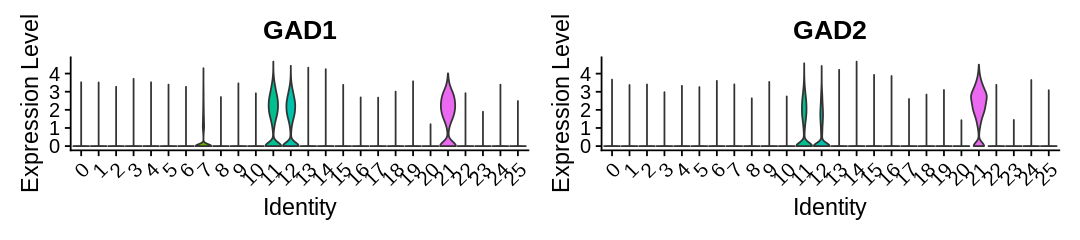

In [30]:
options(repr.plot.width = 9, repr.plot.height = 2)
inN_genes <- c("GAD1", "GAD2")
VlnPlot(scRNA.combined_datas5, 
        features = inN_genes, 
        pt.size=0, ncol=2)

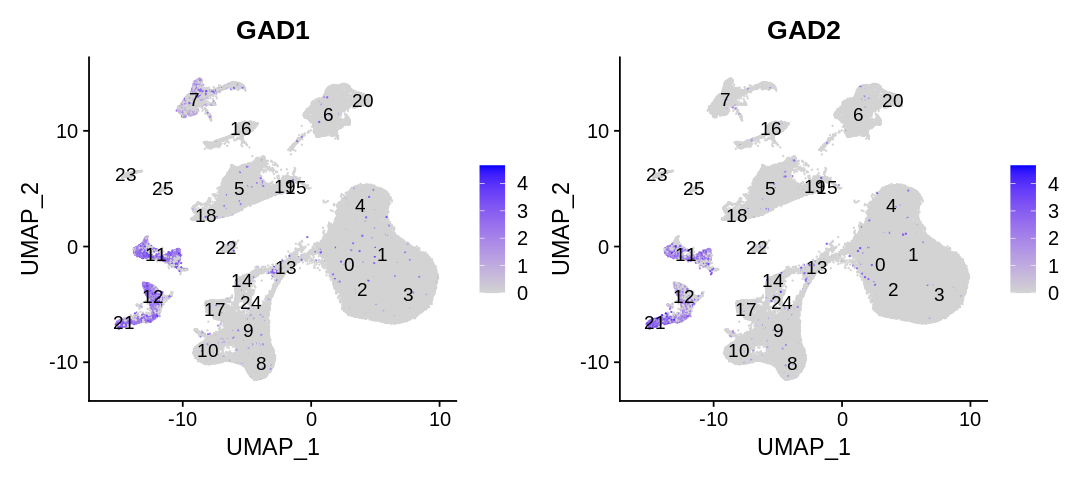

In [31]:
options(repr.plot.width = 9, repr.plot.height = 4)
FeaturePlot(scRNA.combined_datas5, features = inN_genes, 
            reduction = "umap", label=T, ncol=2, raster=FALSE)

### Astrocyte

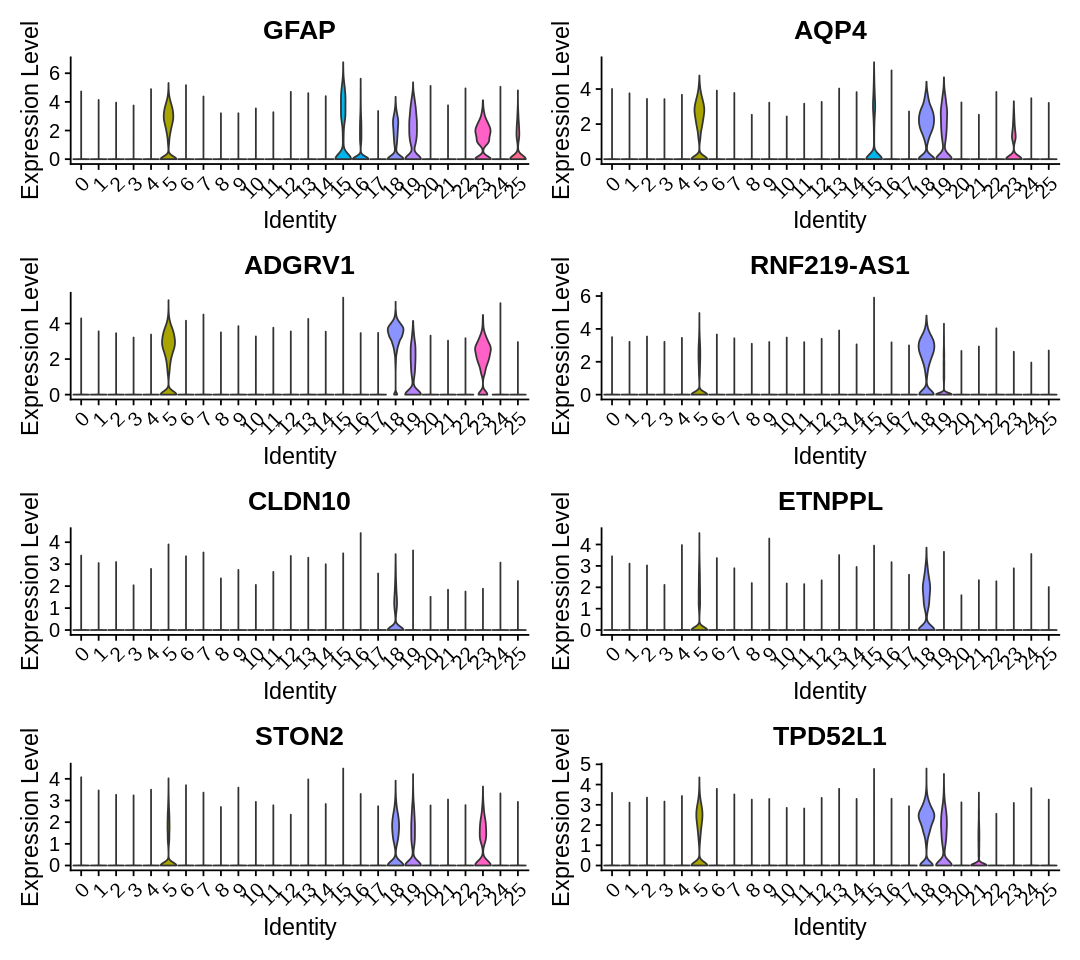

In [32]:
astrocytes_genes <- c("GFAP", "AQP4", "ADGRV1", "RNF219-AS1", "CLDN10", 
                      "ETNPPL", "STON2", 'TPD52L1')
options(repr.plot.width = 9, repr.plot.height = 8)
VlnPlot(scRNA.combined_datas5, 
        features = astrocytes_genes, 
        pt.size=0, ncol=2, raster=FALSE)

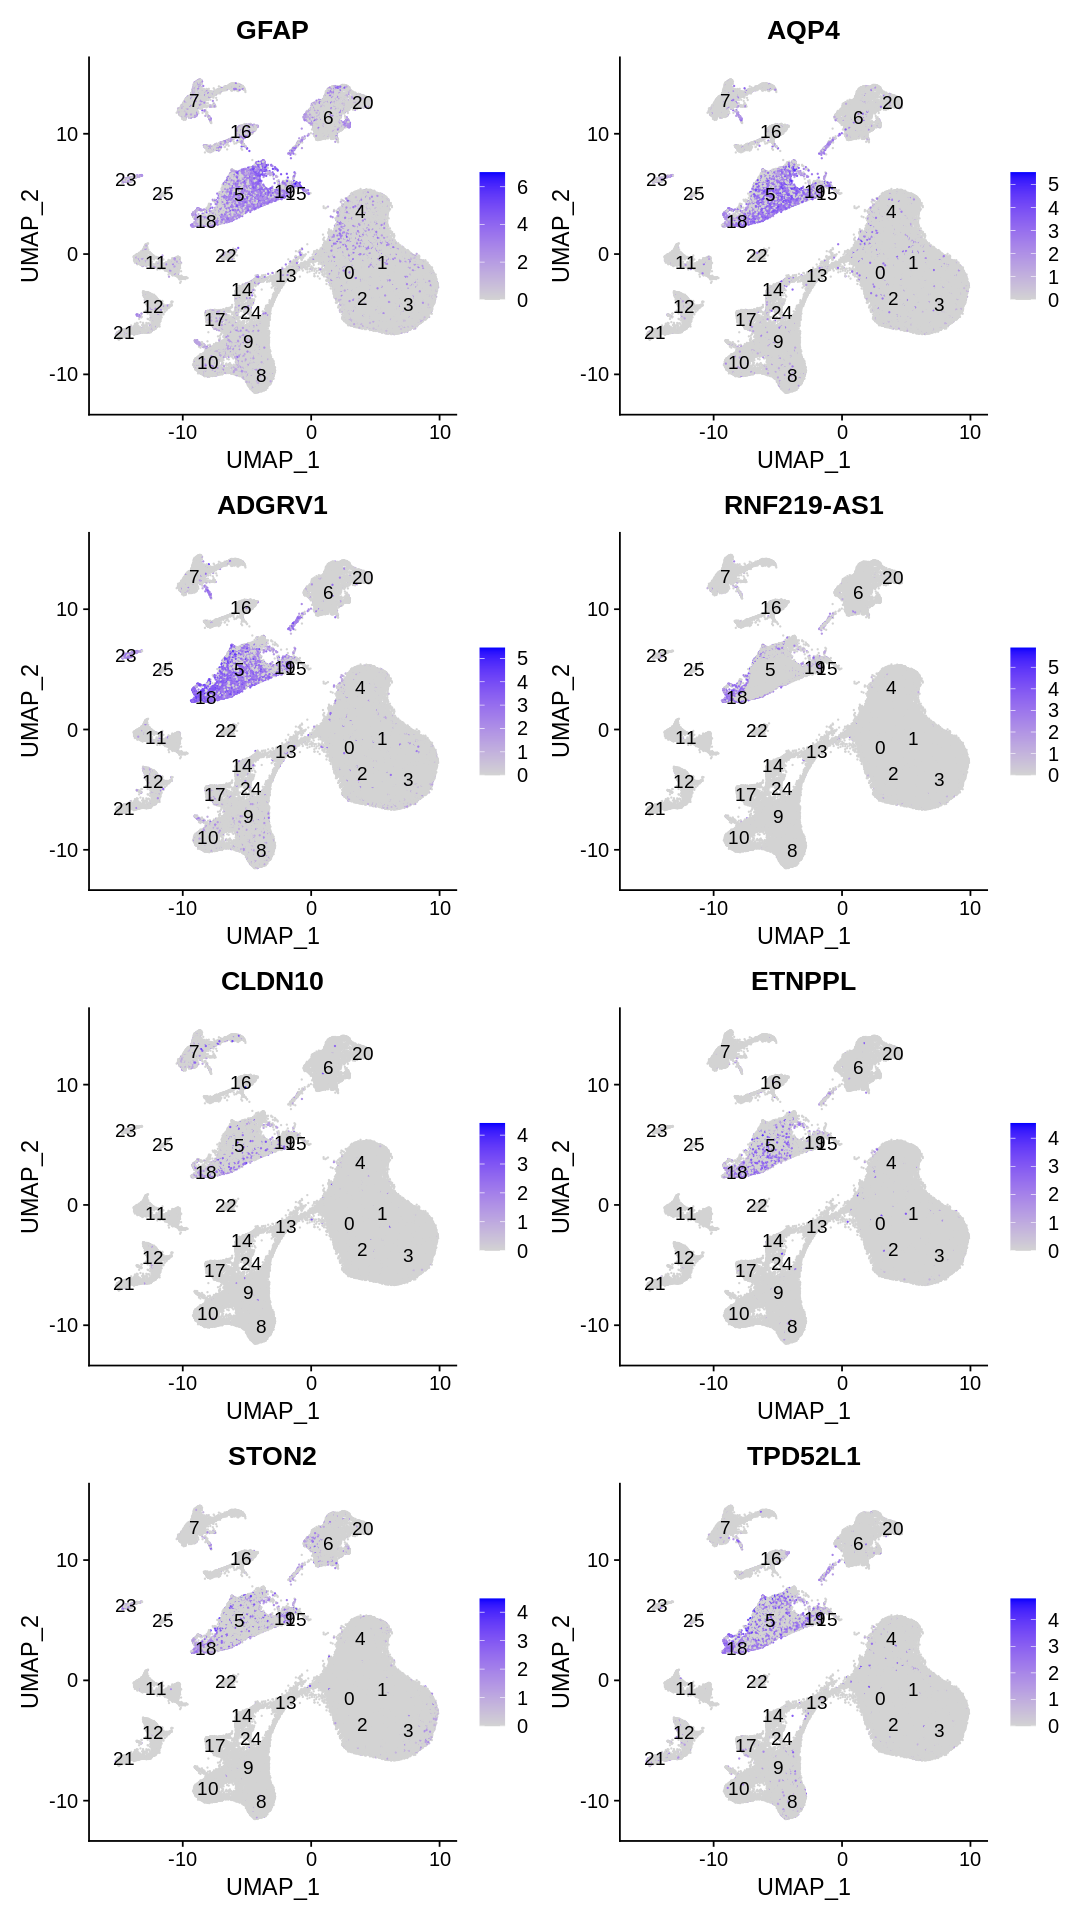

In [33]:
options(repr.plot.width = 9, repr.plot.height = 16)
FeaturePlot(scRNA.combined_datas5, 
            features = astrocytes_genes, 
            reduction = "umap", label=T, ncol=2, raster=FALSE)

### Microglia

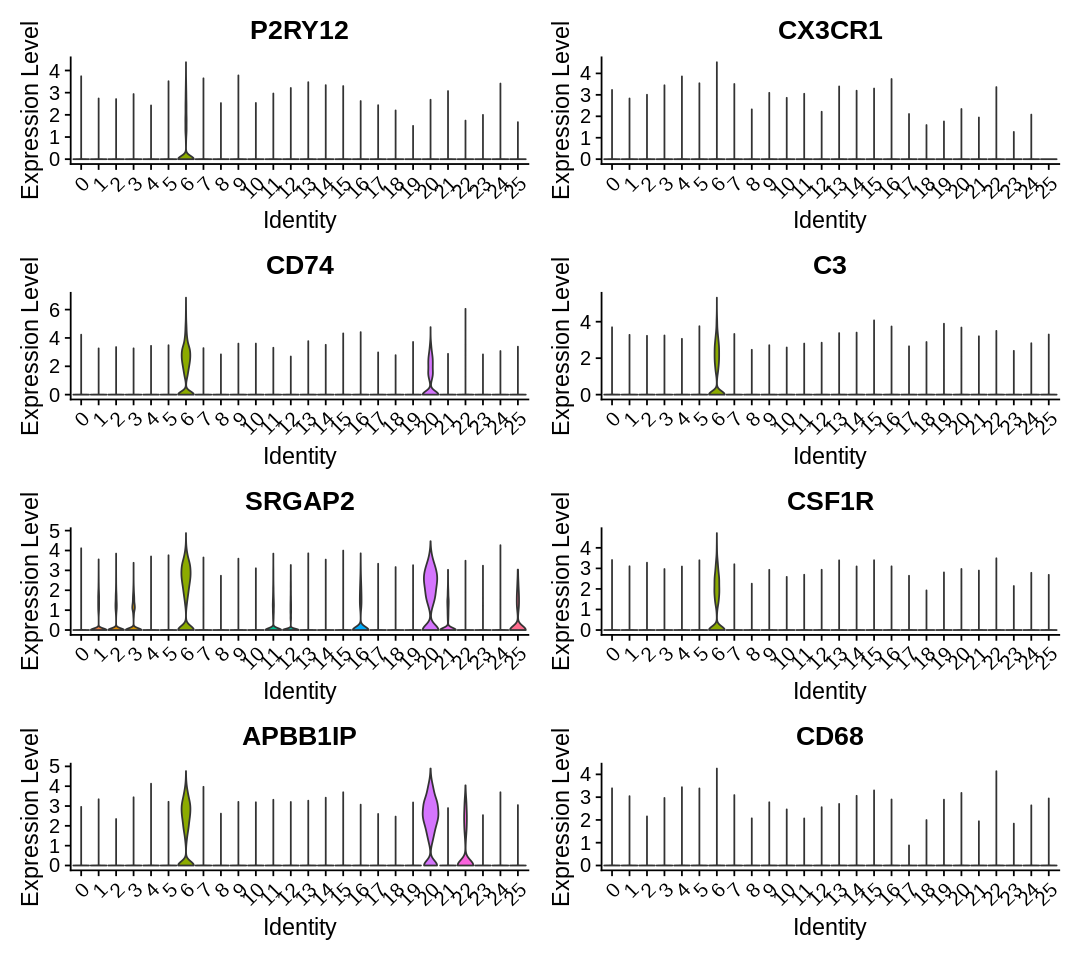

In [34]:
microglia_genes <- c("P2RY12","CX3CR1","CD74","C3",
                     "SRGAP2","CSF1R","APBB1IP","CD68")
options(repr.plot.width = 9, repr.plot.height = 8)
VlnPlot(scRNA.combined_datas5, features = microglia_genes, 
        pt.size=0, ncol=2)

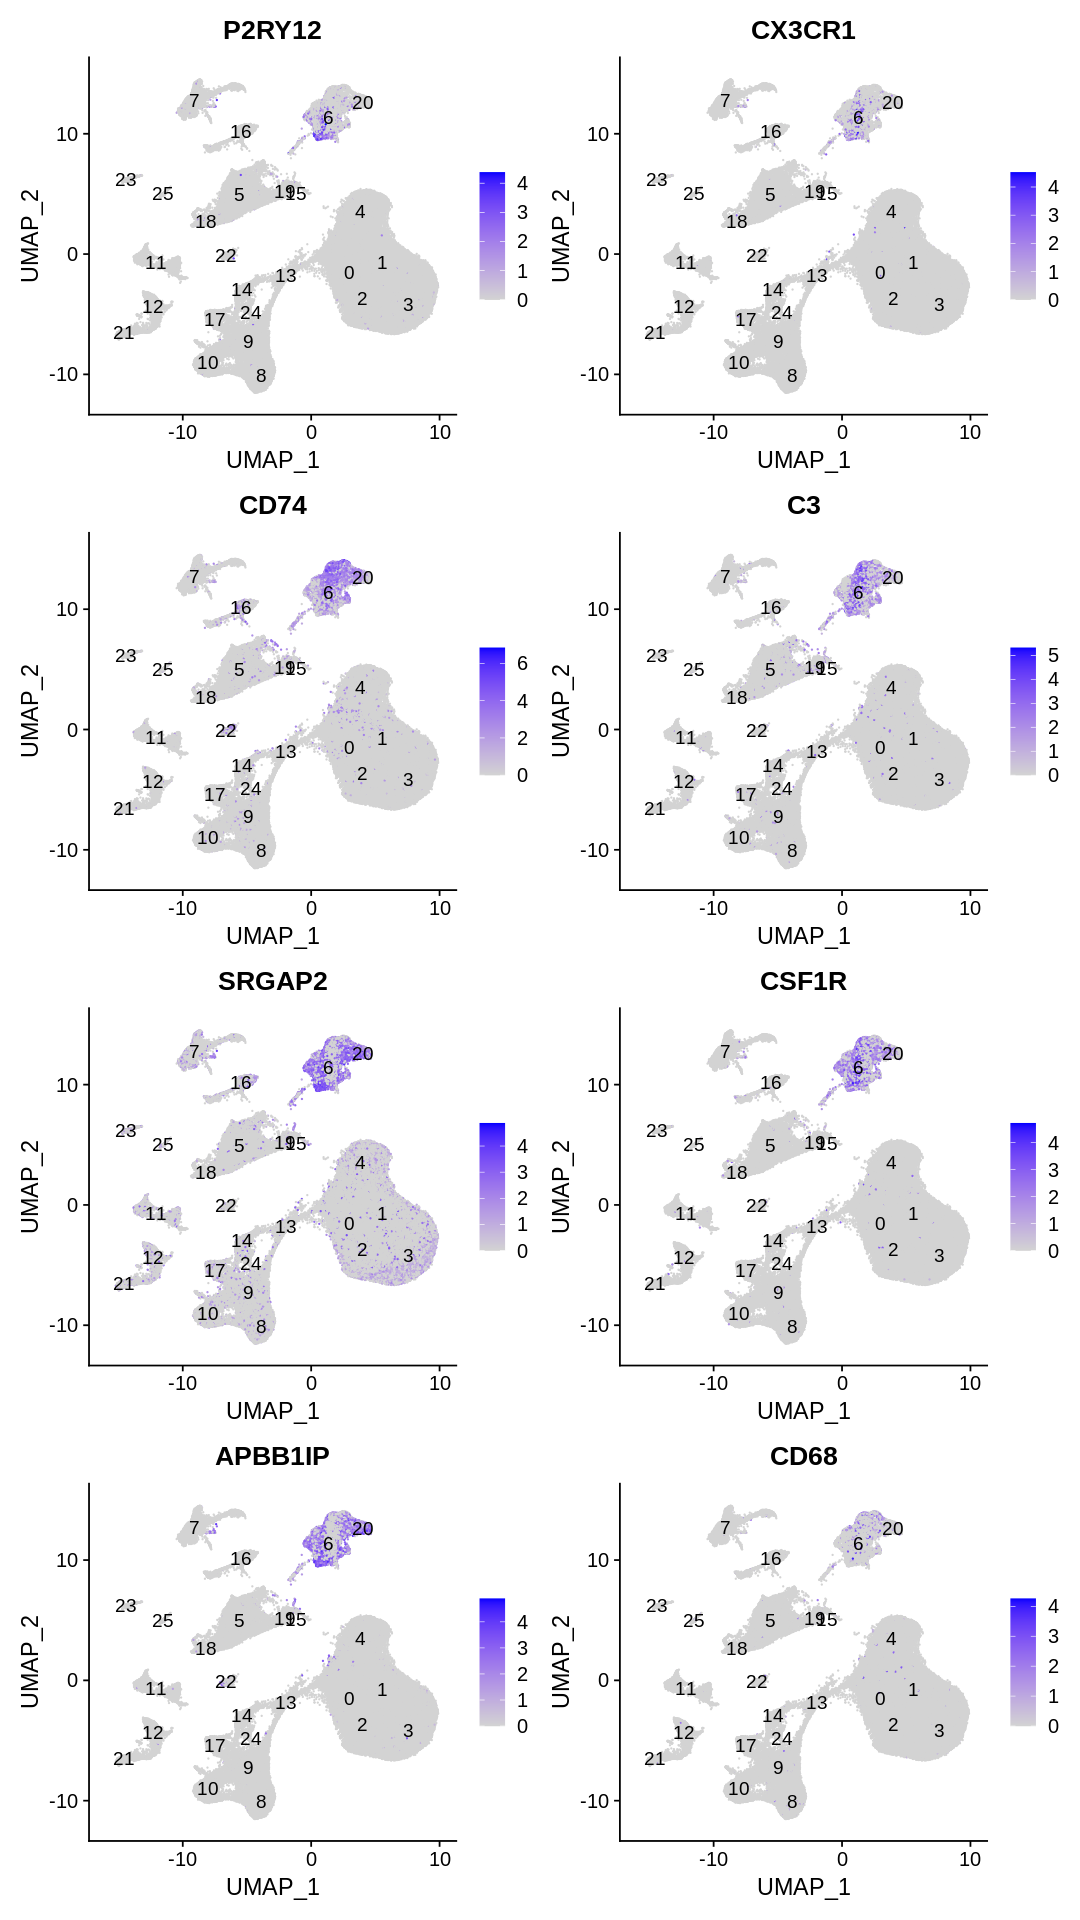

In [35]:
options(repr.plot.width = 9, repr.plot.height = 16)
FeaturePlot(scRNA.combined_datas5, features = microglia_genes, 
            reduction = "umap", label=T, ncol=2, raster=FALSE)

### Endothelial

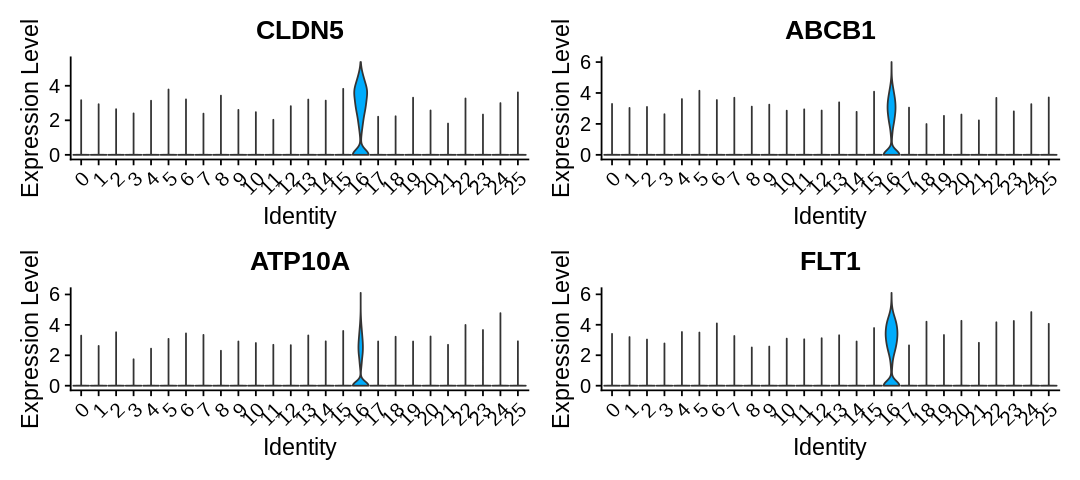

In [36]:
Endothelial_genes <- c("CLDN5", "ABCB1", "ATP10A", "FLT1")
options(repr.plot.width = 9, repr.plot.height = 4)
VlnPlot(scRNA.combined_datas5, features = Endothelial_genes, 
        pt.size=0, ncol=2, raster=FALSE)

null device 
          1

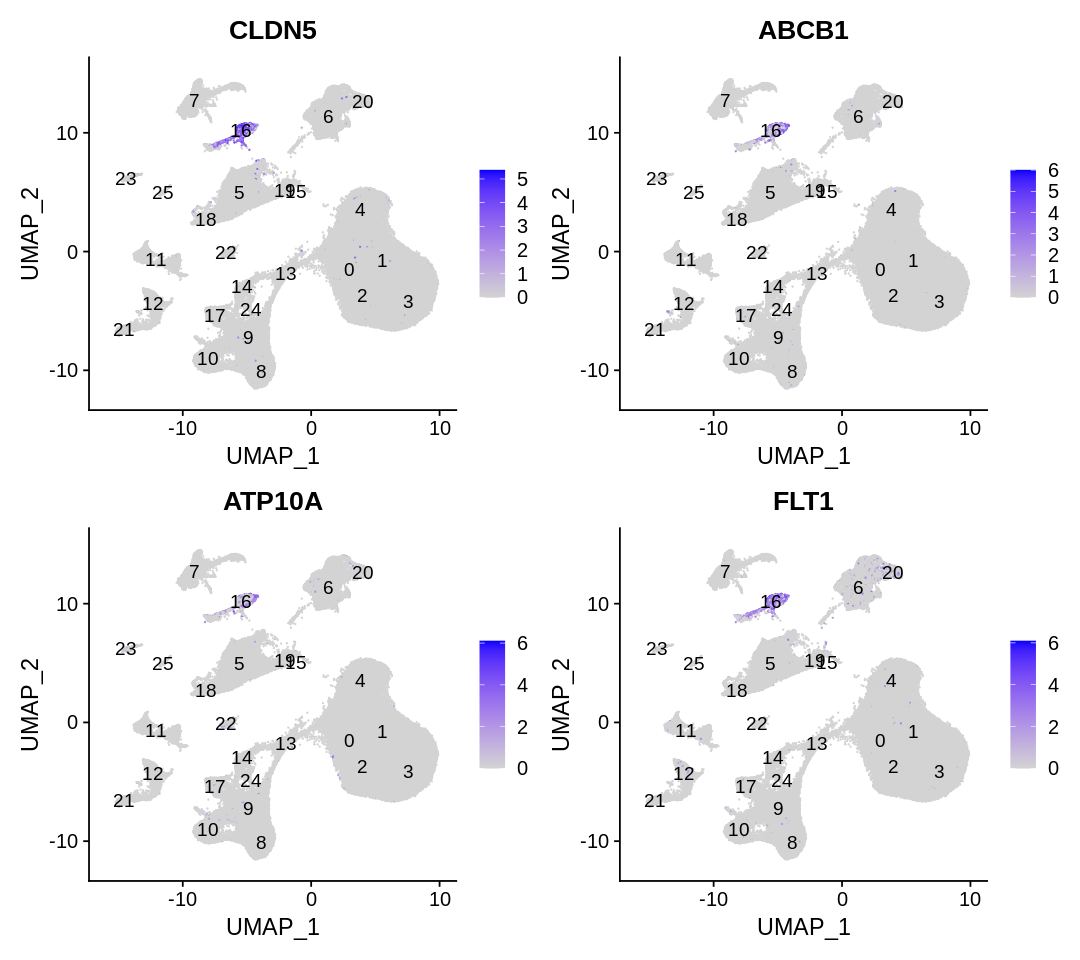

In [37]:
options(repr.plot.width = 9, repr.plot.height = 8)
FeaturePlot(scRNA.combined_datas5, features = Endothelial_genes, 
            reduction = "umap", label=T, ncol=2, raster=FALSE)

In [38]:
celltype <- c(
  "OL", "OL", "OL", "OL", "OL",
  "AST", "MG", "OPC", "Ex-Neuron", "Ex-Neuron",
  "Ex-Neuron", "In-Neuron", "In-Neuron", "Neuron.Mix", "In-Neuron",
  "AST_OL", "Endo", "Ex-Neuron", "AST", "AST",
  "MG", "In-Neuron", "Imm", "AST2", "Neurons*", "Vasc"
)
names(celltype) <- levels(scRNA.combined_datas5)

In [40]:
library(tidyverse)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ tibble  3.2.1     ✔ dplyr   1.1.2
✔ tidyr   1.3.1     ✔ stringr 1.5.0
✔ readr   2.1.4     ✔ forcats 1.0.0
✔ purrr   1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


In [41]:
scRNA.combined_datas5_addcelltype <- scRNA.combined_datas5 %>%
  RenameIdents(celltype) %>% 
  AddMetaData(metadata = data.frame(CellType = Idents(.)))

In [42]:
head(scRNA.combined_datas5_addcelltype@meta.data,2)

,orig.ident,nCount_RNA,nFeature_RNA,source.article,Sample_title,Diagnosis,Lesion_region,Lregion_sym,Clinical.disease.course,Age,Sex,ref_celltype,percent.mt,seurat_clusters,CellType
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<fct>,<fct>
fcx8_GGACGCCTTTAA,2018_Lake,412,359,Lake et al. 2018,fcx8,Control,Control,Control,Control,49,Female,Ex1,0,13,Neuron.Mix
fcx1_GTTCCAGCACGA,2018_Lake,4976,2964,Lake et al. 2018,fcx1,Control,Control,Control,Control,22,Male,Ex1,0,8,Ex-Neuron


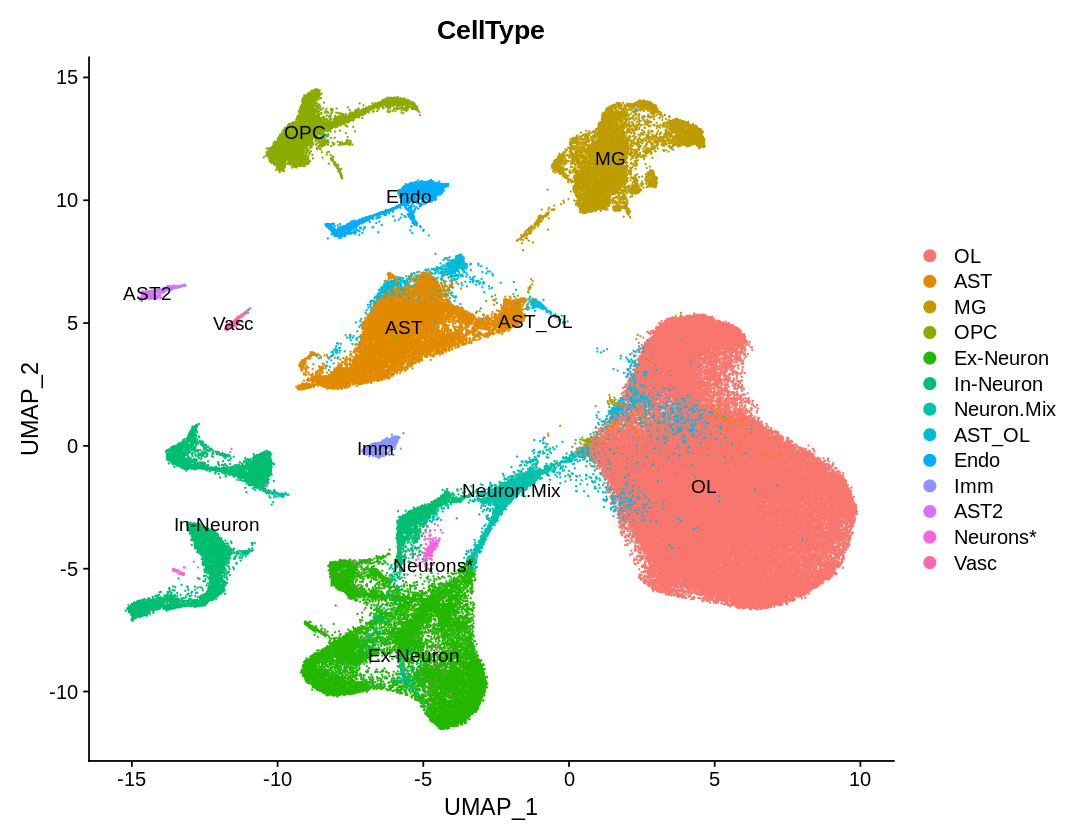

In [43]:
options(repr.plot.width = 9, repr.plot.height = 7)
DimPlot(scRNA.combined_datas5_addcelltype, reduction = "umap", 
        group.by = "CellType", 
        label = TRUE, raster=FALSE)

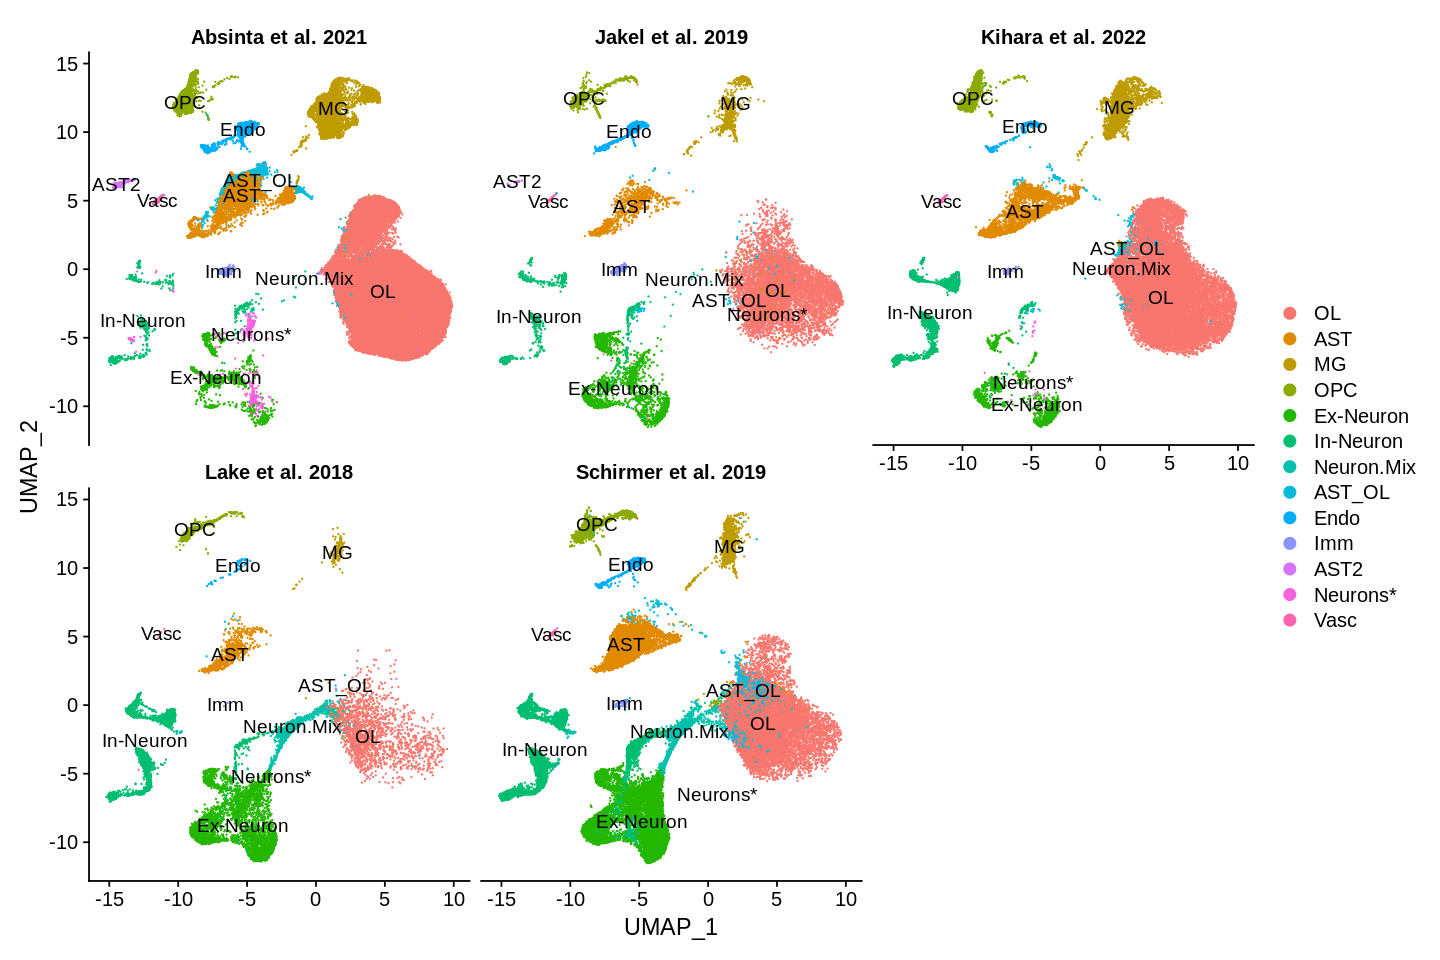

In [44]:
options(repr.plot.width = 12, repr.plot.height = 8)
DimPlot(scRNA.combined_datas5_addcelltype, reduction = "umap", 
        split.by = "source.article", ncol = 3,
        label = TRUE, raster = FALSE)

In [45]:
scRNA.combined_datas5_addcelltype <- subset(
    scRNA.combined_datas5_addcelltype, 
    CellType != "AST_OL" & CellType != "AST2" & 
    CellType != "Neuron.Mix" & 
    CellType != "Neurons*")

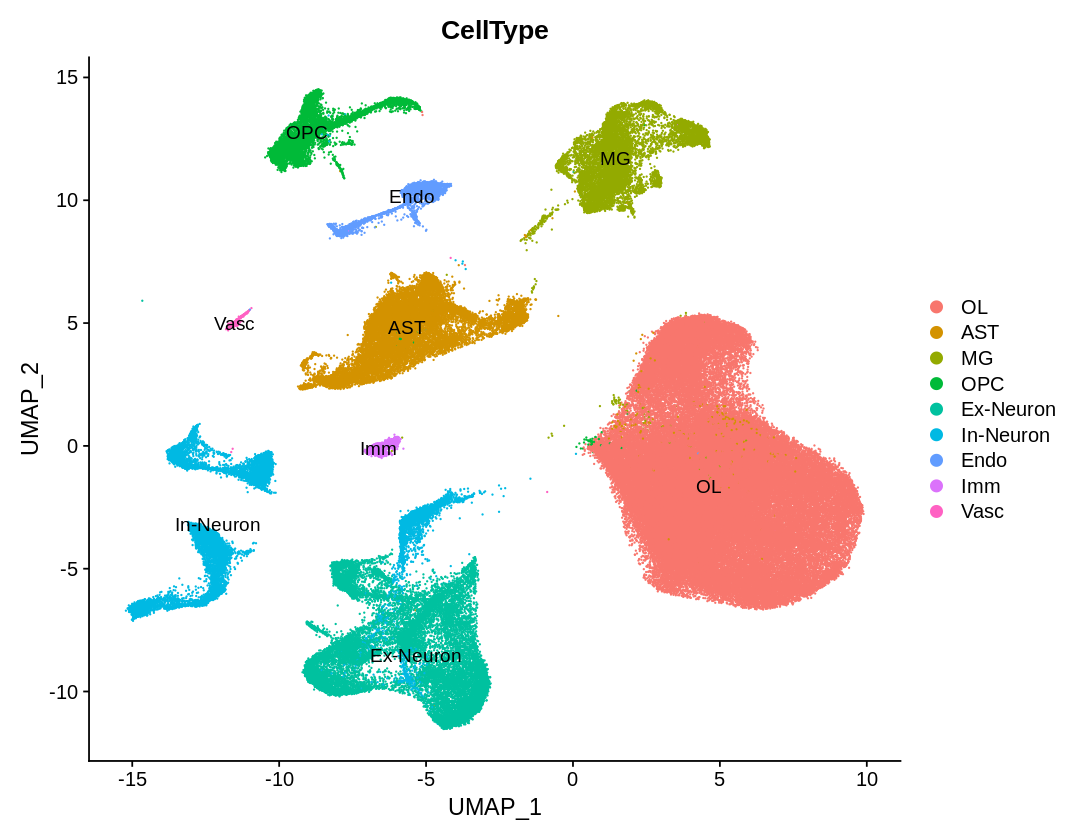

In [46]:
options(repr.plot.width = 9, repr.plot.height = 7)
DimPlot(scRNA.combined_datas5_addcelltype, reduction = "umap", 
        group.by = "CellType", 
        label = TRUE, raster=FALSE)

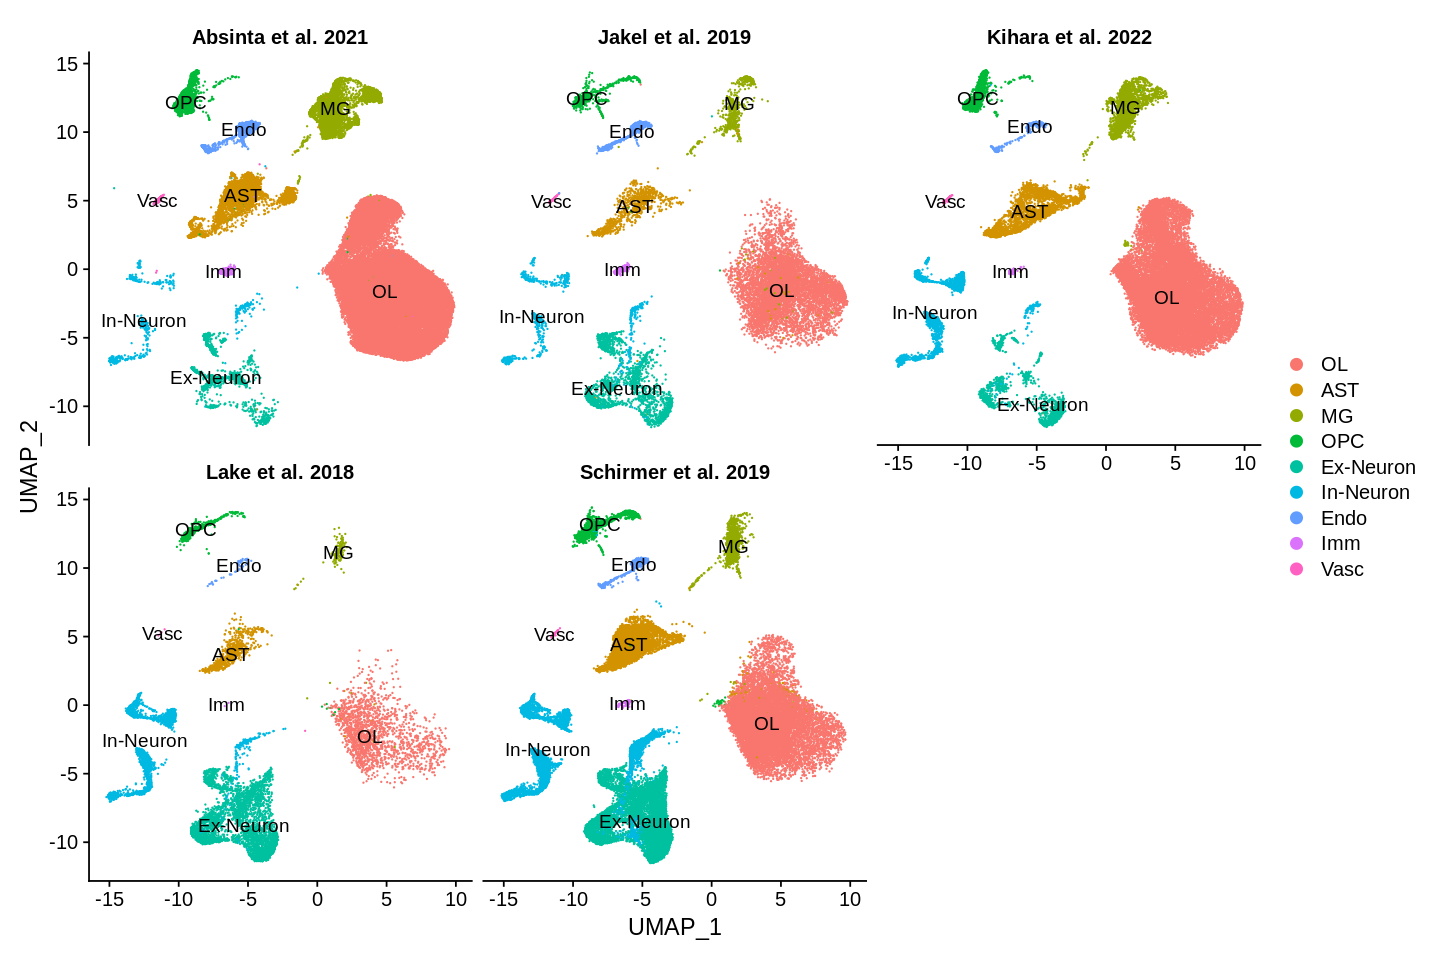

In [47]:
options(repr.plot.width = 12, repr.plot.height = 8)
DimPlot(scRNA.combined_datas5_addcelltype, reduction = "umap", 
        split.by = "source.article", ncol = 3,
        label = TRUE, raster = FALSE)

In [48]:
saveRDS(scRNA.combined_datas5_addcelltype, 
        "result_LSA/scRNA.combined_datas5_addCellType.Rds")

In [49]:
celltype_colors <- c(
    "OPC" = "#61A334",
    "MG" = "#27A5C3",
    "Endo" = "#3B90C7",
    "AST" = "#61A334",
    "AST2" = "#37A659",
    "Vasc" = "#927EB3",
    "OL" = "#A39A23",
    "Imm" = "#2DAB96",
    "In-Neuron" = "#CB8816",
    "Ex-Neuron" = "#E07067"
)

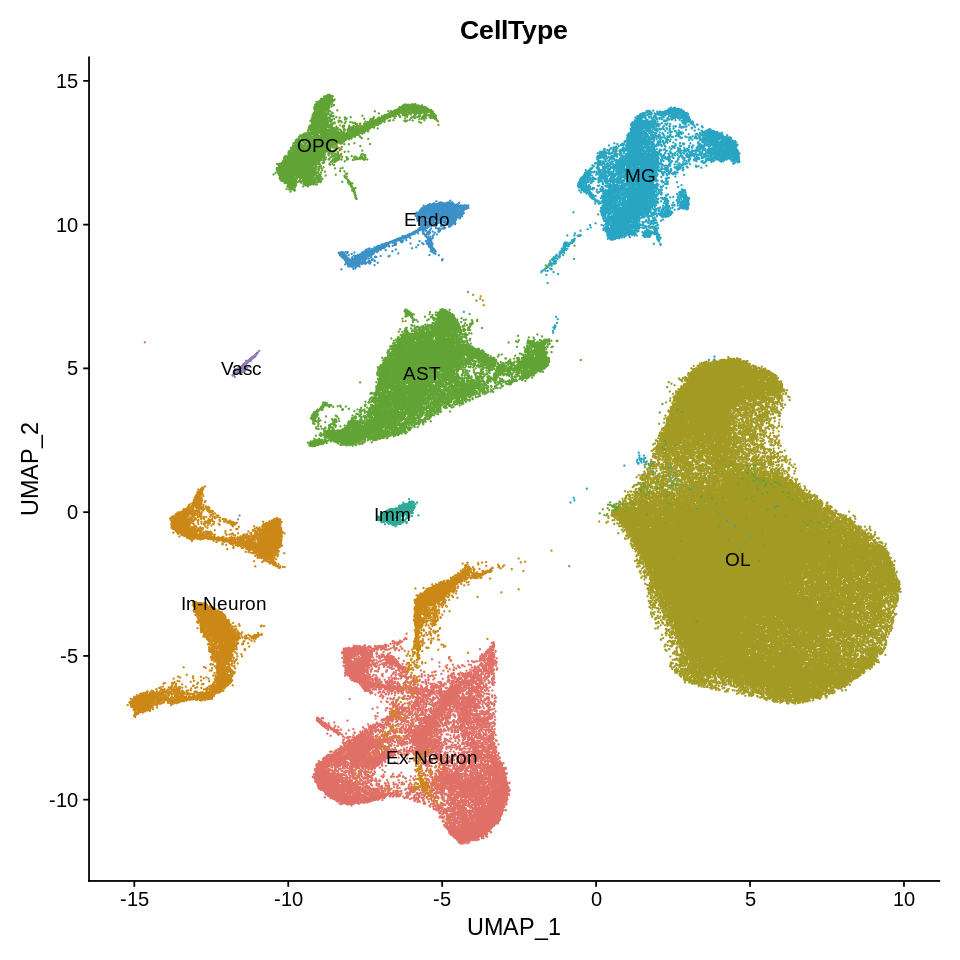

In [50]:
options(repr.plot.width = 8, repr.plot.height = 8)
DimPlot(scRNA.combined_datas5_addcelltype, reduction = "umap", 
    group.by = "CellType", 
    label = TRUE, raster=FALSE, cols = celltype_colors) + NoLegend()

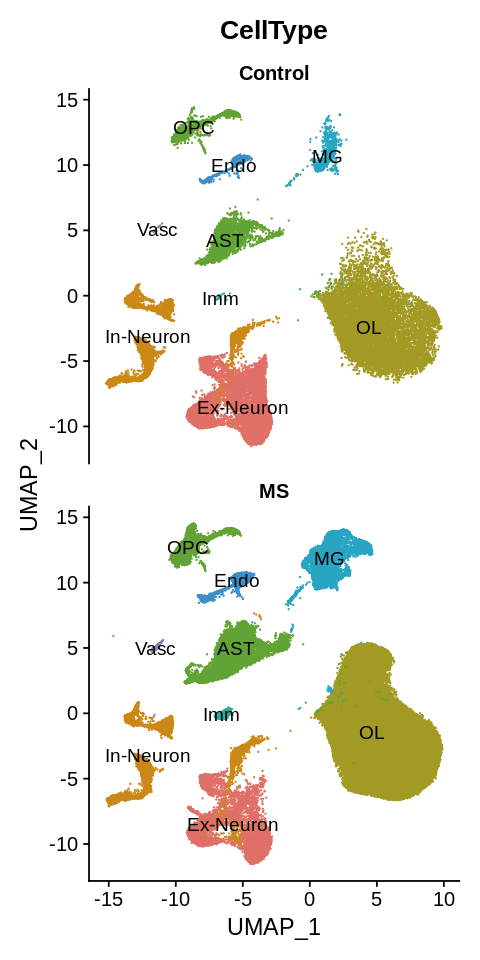

In [51]:
options(repr.plot.width = 4, repr.plot.height = 8)
DimPlot(scRNA.combined_datas5_addcelltype, reduction = "umap", 
        group.by = "CellType", 
        split.by = "Diagnosis", 
        label = TRUE, raster=FALSE, 
        ncol = 1,
        cols = celltype_colors) + NoLegend()

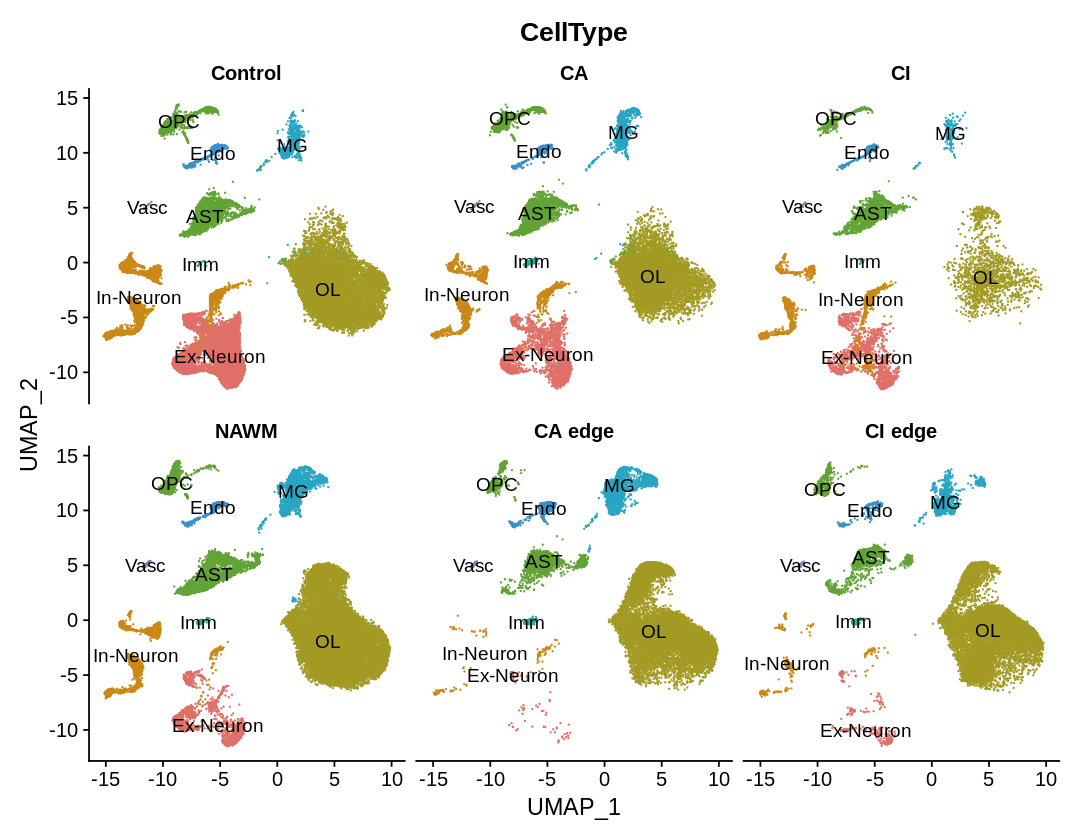

In [52]:
Lregion_order <- c("Control", "CA", "CI", "NAWM", "CA edge", "CI edge")
scRNA.combined_datas5_addcelltype$Lregion_sym <- factor(
  scRNA.combined_datas5_addcelltype$Lregion_sym,
  levels = Lregion_order
)

options(repr.plot.width = 9, repr.plot.height = 7)
DimPlot(
  scRNA.combined_datas5_addcelltype,
  reduction = "umap",
  group.by = "CellType",
  split.by = "Lregion_sym",
  label = TRUE,
  raster = FALSE,
  ncol = 3,
  cols = celltype_colors
) + NoLegend()